 ##  USED CAR PRICE PREDICTION


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# read the data

df_used_car_dataset = pd.read_csv("used_car_dataset.csv")

In [3]:
# read the first five observation of the data

In [4]:
df_used_car_dataset.head()

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,Price(Rs)
0,Honda,City,2001,23,"98,000 km",Manual,second,Petrol,"1,95,000"
1,Toyota,Innova,2009,15,190000.0 km,Manual,second,Diesel,"3,75,000"
2,Volkswagen,VentoTest,2010,14,"77,246 km",Manual,first,Diesel,"1,84,999"
3,Maruti Suzuki,Swift,2017,7,"83,500 km",Manual,second,Diesel,"5,65,000"
4,Maruti Suzuki,Baleno,2019,5,"45,000 km",Automatic,first,Petrol,"6,85,000"


In [5]:
df_used_car_dataset.tail()

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,Price(Rs)
1207,Mahindra,XUV500,2013,11,"49,200 km",Manual,first,Diesel,"5,50,000"
1208,BMW,X5,2021,3,"21,000 km",Automatic,first,Petrol,"80,50,000"
1209,Toyota,Camry,2023,1,"10,000 km",Automatic,first,Petrol,"44,50,000"
1210,Toyota,Innova,2006,18,"170,000 km",Manual,second,Diesel,"2,70,000"
1211,Renault,Duster,2016,8,"63,000 km",Manual,second,Diesel,"4,15,000"


In [6]:
# check the no of observation and attribute

df_used_car_dataset.shape

(1212, 9)

In [7]:
# check the basic info anout the data

df_used_car_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Brand         1212 non-null   str  
 1   model         1212 non-null   str  
 2   Year          1212 non-null   int64
 3   Age           1212 non-null   int64
 4   kmDriven      1203 non-null   str  
 5   Transmission  1212 non-null   str  
 6   Owner         1212 non-null   str  
 7   FuelType      1212 non-null   str  
 8   Price(Rs)     1212 non-null   str  
dtypes: int64(2), str(7)
memory usage: 146.8 KB


# Data Preprocessing

## Missing Value Handling

In [8]:
# check missing value

df_used_car_dataset.isnull().sum()

Brand           0
model           0
Year            0
Age             0
kmDriven        9
Transmission    0
Owner           0
FuelType        0
Price(Rs)       0
dtype: int64

In [9]:
# check the format of kmDriven

df_used_car_dataset["kmDriven"].head(10)

0      98,000 km
1    190000.0 km
2      77,246 km
3      83,500 km
4      45,000 km
5      83,000 km
6     168,000 km
7      25,000 km
8      33,759 km
9      69,713 km
Name: kmDriven, dtype: str

In [10]:
# clean the km_Driven column
# Remove commas and 'km'

df_used_car_dataset["kmDriven"] = (
    df_used_car_dataset["kmDriven"]
    .str.replace(",", "", regex=False)
    .str.replace("km", "", regex=False)
    .str.strip()
)

# Convert to numeric
df_used_car_dataset["kmDriven"] = pd.to_numeric(
    df_used_car_dataset["kmDriven"],
    errors="coerce"
)

In [11]:
# check the result

df_used_car_dataset["kmDriven"].head(10)

0     98000.0
1    190000.0
2     77246.0
3     83500.0
4     45000.0
5     83000.0
6    168000.0
7     25000.0
8     33759.0
9     69713.0
Name: kmDriven, dtype: float64

In [12]:
# fill the missing value

df_used_car_dataset["kmDriven"] = df_used_car_dataset["kmDriven"].fillna(
    df_used_car_dataset["kmDriven"].median()
)

In [13]:
# verify

df_used_car_dataset["kmDriven"].isnull().sum()

np.int64(0)

In [14]:
# clean the Price(Rs) column

df_used_car_dataset["Price(Rs)"].head(10)

0      1,95,000
1      3,75,000
2      1,84,999
3      5,65,000
4      6,85,000
5     13,50,000
6     10,25,000
7     59,50,000
8      6,22,000
9      6,49,000
Name: Price(Rs), dtype: str

In [15]:
# Remove commas

df_used_car_dataset["Price(Rs)"] = (
    df_used_car_dataset["Price(Rs)"]
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric
df_used_car_dataset["Price(Rs)"] = pd.to_numeric(
    df_used_car_dataset["Price(Rs)"],
    errors="coerce"
)

In [16]:
# verify

df_used_car_dataset["Price(Rs)"].head(10)

0     195000
1     375000
2     184999
3     565000
4     685000
5    1350000
6    1025000
7    5950000
8     622000
9     649000
Name: Price(Rs), dtype: int64

In [17]:
# check for missing value

df_used_car_dataset["Price(Rs)"].isnull().sum()

np.int64(0)

In [18]:
df_used_car_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         1212 non-null   str    
 1   model         1212 non-null   str    
 2   Year          1212 non-null   int64  
 3   Age           1212 non-null   int64  
 4   kmDriven      1212 non-null   float64
 5   Transmission  1212 non-null   str    
 6   Owner         1212 non-null   str    
 7   FuelType      1212 non-null   str    
 8   Price(Rs)     1212 non-null   int64  
dtypes: float64(1), int64(3), str(5)
memory usage: 124.8 KB


In [19]:
# interpretation
# we have 4 numerical columns and 5 categorical columns
# we don't have the missing record on the data

## Remove duplicate values

In [20]:
# check duplicates

df_used_car_dataset.duplicated().sum()

np.int64(44)

In [21]:
# remove duplicates

df_used_car_dataset.drop_duplicates(inplace=True)

In [22]:
# verify

df_used_car_dataset.duplicated().sum()

np.int64(0)

In [23]:
df_used_car_dataset.shape


(1168, 9)

In [24]:
print('\nTransmission: ')
print(df_used_car_dataset['Transmission'].value_counts())
print('\nOwner: ')
print(df_used_car_dataset['Owner'].value_counts())
print('\nFuelType: ')
df_used_car_dataset['FuelType'].value_counts()



Transmission: 
Transmission
Manual       586
Automatic    582
Name: count, dtype: int64

Owner: 
Owner
first     618
second    550
Name: count, dtype: int64

FuelType: 


FuelType
Diesel    596
Petrol    572
Name: count, dtype: int64

In [25]:
df_used_car_dataset['Brand'].value_counts()

Brand
Maruti Suzuki    250
Hyundai          186
Toyota           119
Honda             89
Mahindra          84
Mercedes-Benz     57
Tata              53
Volkswagen        50
BMW               49
Audi              38
Ford              34
Renault           32
Kia               27
Skoda             24
MG                13
Mini              10
Land Rover         9
Jeep               8
Volvo              6
Jaguar             6
Chevrolet          5
Fiat               3
Porsche            3
Nissan             3
Isuzu              3
Mitsubishi         2
Lexus              2
Aston Martin       1
Force              1
Datsun             1
Name: count, dtype: int64

## Data cleaning

In [26]:
# Renaming action

df_used_car_dataset.columns


Index(['Brand', 'model', 'Year', 'Age', 'kmDriven', 'Transmission', 'Owner',
       'FuelType', 'Price(Rs)'],
      dtype='str')

In [27]:
# create the dictionary for new column assignment

dictionary1 = { 'Brand' : 'Brand'  , 
                'model' : 'model' ,
                'Year' : 'Year' ,
                'Age' : 'Age', 
                'kmDriven': 'km_Driven' , 
                'Transmission' : 'Transmission', 
                'Owner' : 'Owner' ,
                'FuelType' :  'FuelType', 
                'Price(Rs)' : 'Price(Rs)'
              }

In [28]:
# perform the renaming

df_used_car_dataset = df_used_car_dataset.rename(columns=dictionary1)

In [29]:
# authentic check

df_used_car_dataset.columns

Index(['Brand', 'model', 'Year', 'Age', 'km_Driven', 'Transmission', 'Owner',
       'FuelType', 'Price(Rs)'],
      dtype='str')

In [30]:
# statistical summary

df_used_car_dataset.describe()

,Year,Age,km_Driven,Price(Rs)
count,1168.000000,1168.000000,1168.000000,1.168000e+03
mean,2016.529966,7.470034,69364.151541,1.282015e+06
std,4.081113,4.081113,55393.972083,2.088974e+06
min,1994.000000,0.000000,0.000000,2.000000e+04
25%,2014.000000,5.000000,39000.000000,4.232500e+05
50%,2017.000000,7.000000,64900.000000,6.970000e+05
75%,2019.000000,10.000000,86000.000000,1.450000e+06
max,2024.000000,30.000000,800000.000000,2.775000e+07


In [31]:
df_used_car_dataset.dtypes

Brand               str
model               str
Year              int64
Age               int64
km_Driven       float64
Transmission        str
Owner               str
FuelType            str
Price(Rs)         int64
dtype: object

In [32]:
df_used_car_dataset.nunique()

Brand            30
model           226
Year             25
Age              25
km_Driven       394
Transmission      2
Owner             2
FuelType          2
Price(Rs)       492
dtype: int64

In [33]:
df_used_car_dataset['Brand'].unique()

<ArrowStringArray>
[        'Honda',        'Toyota',    'Volkswagen', 'Maruti Suzuki',
           'BMW',          'Ford',           'Kia', 'Mercedes-Benz',
       'Hyundai',          'Audi',       'Renault',            'MG',
         'Volvo',         'Skoda',          'Tata',      'Mahindra',
          'Mini',    'Land Rover',          'Jeep',     'Chevrolet',
        'Jaguar',          'Fiat',  'Aston Martin',       'Porsche',
        'Nissan',         'Force',    'Mitsubishi',         'Lexus',
         'Isuzu',        'Datsun']
Length: 30, dtype: str

# EDA (Exploratory Data Analysis)

## Univariate analysis

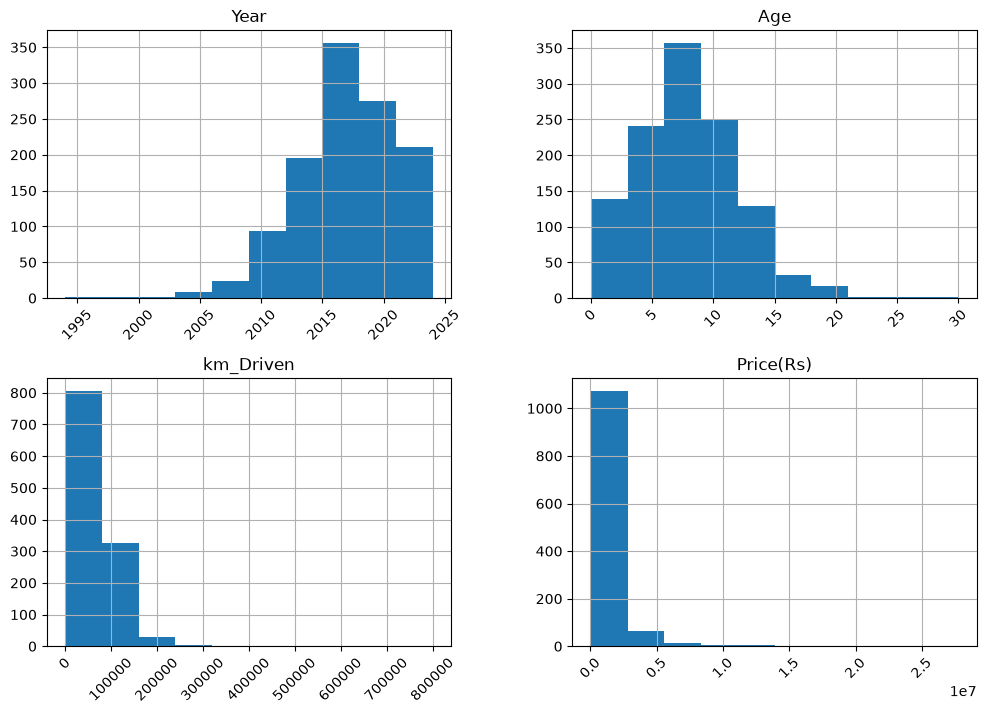

In [34]:
# Numerical columns

import matplotlib.pyplot as plt
df_used_car_dataset.hist(figsize=(12,8))
for ax in plt.gcf().axes:
    ax.tick_params(axis='x', rotation=45)
plt.show()

In [35]:
# Inference 
# for Year
# Most cars in the dataset were manufactured between 2014 and 2022.
# The highest number of cars belongs to the 2016–2019 model years.
# Very few cars were manufactured before 2010.

# for Age
# Most cars are 5 to 10 years old.
# Very few cars are older than 15 years.

# for km_Driven
# Most vehicles have been driven less than 100,000 km.
# As the kilometres driven increase, the number of cars decreases.
# A few vehicles have extremely high mileage (above 200,000 km), which appear to be outliers.

# for Price(Rs)
# Most cars are priced in the lower price range.
# Only a small number of vehicles have very high selling prices.

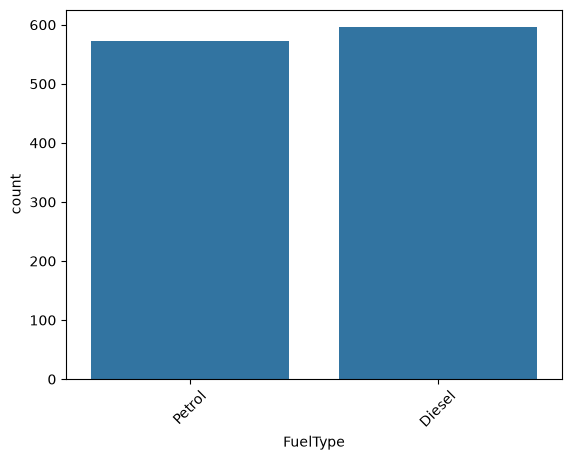

In [36]:
# Categorical columns

sns.countplot(x='FuelType', data=df_used_car_dataset)
plt.xticks(rotation=45)
plt.show()

In [37]:
# Inference 
# The number of Diesel cars is slightly higher than the number of Petrol cars.

In [38]:
# segregate the data based on this data types

df_num = df_used_car_dataset.select_dtypes(include='number')
df_cat = df_used_car_dataset.select_dtypes(include='str')

In [39]:
# show the numerical columns

df_num.columns

Index(['Year', 'Age', 'km_Driven', 'Price(Rs)'], dtype='str')

In [40]:
df_cat.columns

Index(['Brand', 'model', 'Transmission', 'Owner', 'FuelType'], dtype='str')

In [41]:
df_cat.Owner.value_counts()

Owner
first     618
second    550
Name: count, dtype: int64

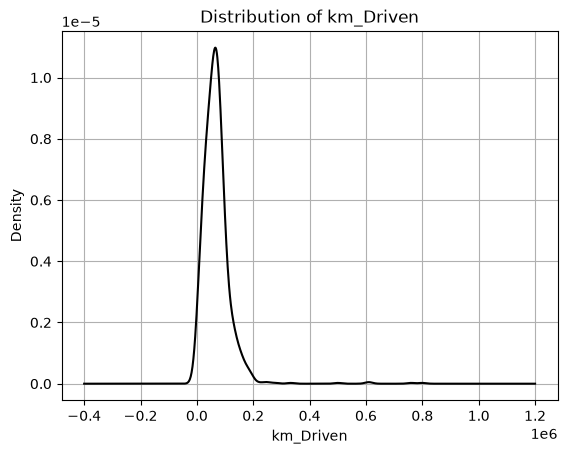

In [42]:
# KDE plot

df_num.km_Driven.plot(kind='kde', color = 'black')
plt.grid()
plt.title('Distribution of km_Driven')
plt.xlabel('km_Driven')
plt.show()

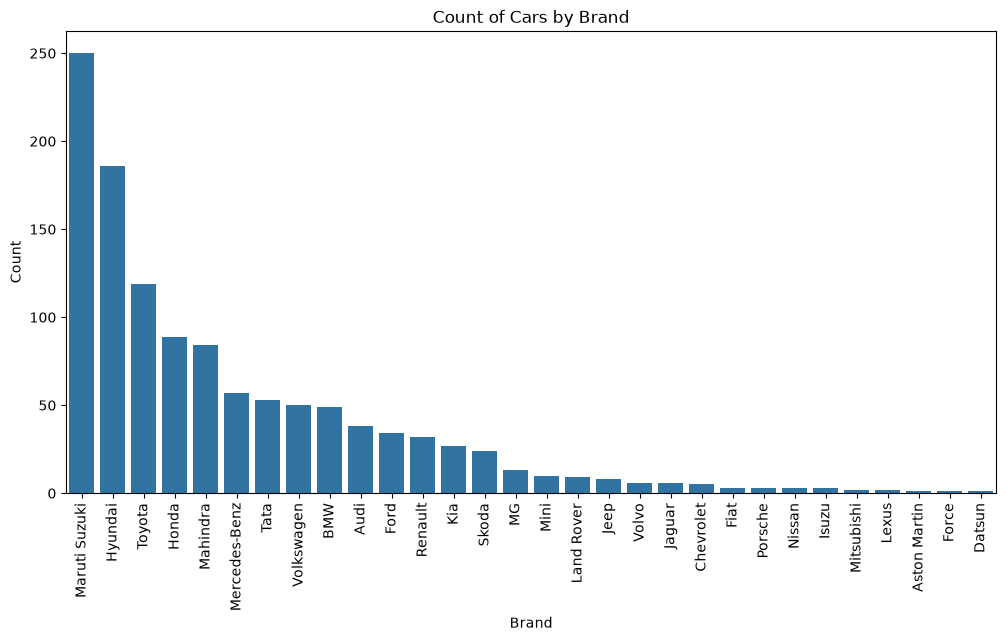

In [43]:
# plot the countplot for Brand

plt.figure(figsize=(12,6))
sns.countplot(x='Brand', data=df_used_car_dataset, order=df_used_car_dataset['Brand'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Count of Cars by Brand")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.show()



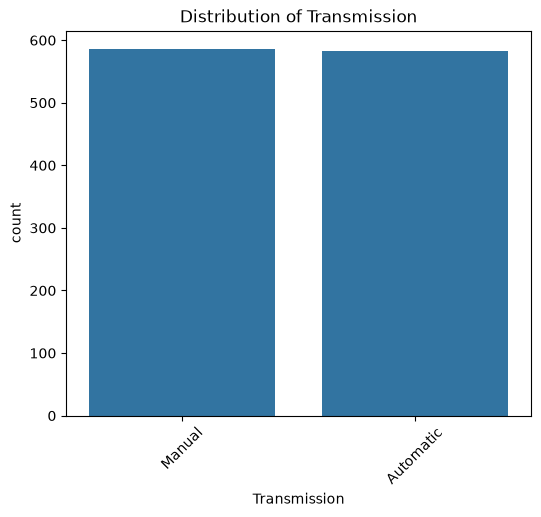

In [44]:
# Transmission

plt.figure(figsize=(6,5))
sns.countplot(data=df_used_car_dataset,
              x='Transmission')

plt.xticks(rotation=45)
plt.title('Distribution of Transmission')
plt.show()

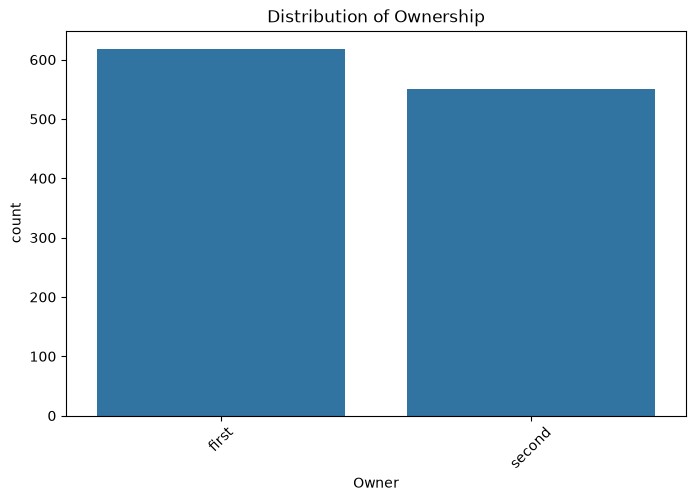

In [45]:
# owner

plt.figure(figsize=(8,5))
sns.countplot(data=df_used_car_dataset,
              x='Owner',
              order=df_used_car_dataset['Owner'].value_counts().index)

plt.xticks(rotation=45)
plt.title('Distribution of Ownership')
plt.show()

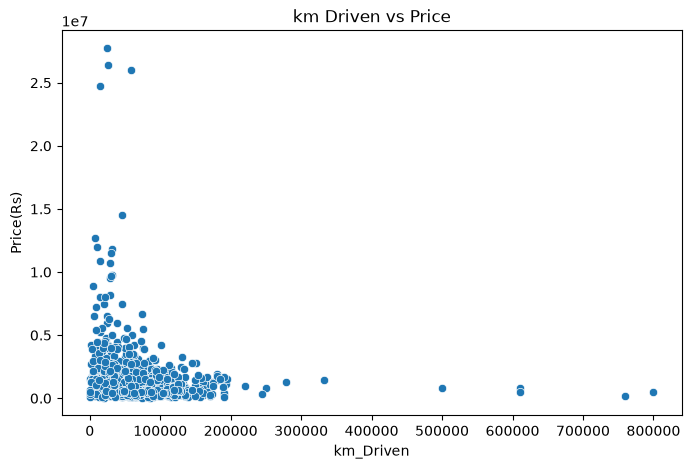

In [46]:
# km_Driven vs Price

plt.figure(figsize=(8,5))
sns.scatterplot(data=df_used_car_dataset, x='km_Driven', y='Price(Rs)')
plt.title('km Driven vs Price')
plt.show()

## Bivariate Analysis

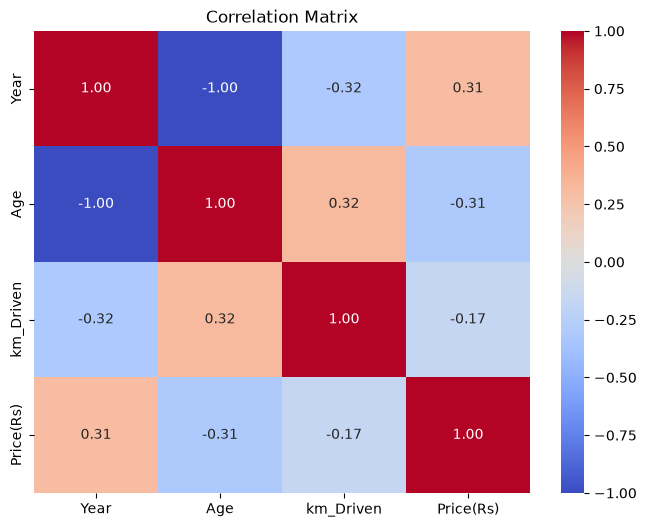

In [47]:
# correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df_num.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Matrix")
plt.show()

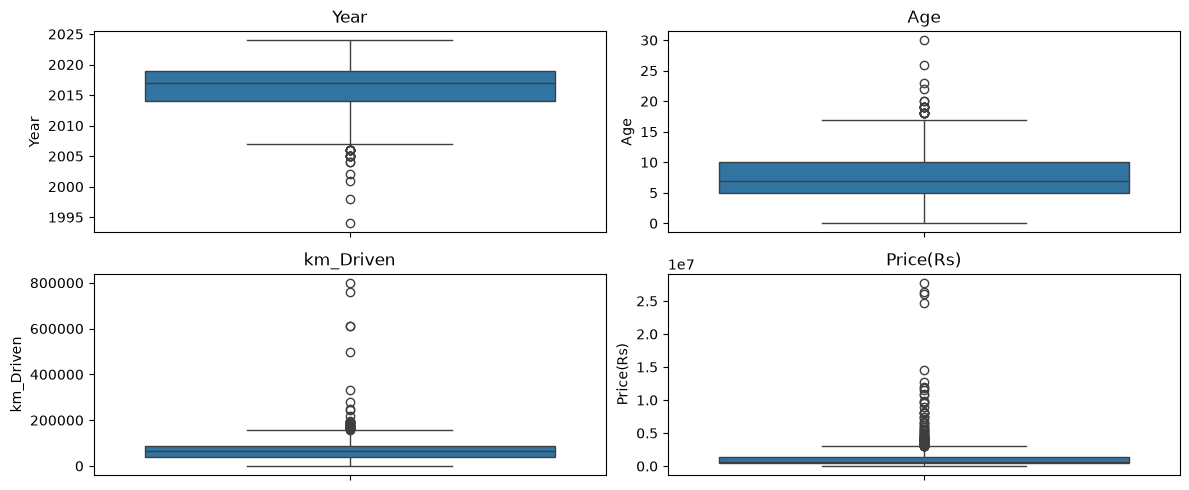

In [48]:
# outlier detection

plt.figure(figsize=(12,5))

for i, col in enumerate(df_num.columns):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df_used_car_dataset[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [49]:
# Encode categorical variables

from sklearn.preprocessing import LabelEncoder
import joblib

cat_cols = ['Brand', 'model', 'Transmission', 'Owner', 'FuelType']

encoders = {}
mappings = {}

for col in cat_cols:
    le = LabelEncoder()

    df_used_car_dataset[col] = le.fit_transform(df_used_car_dataset[col])

    encoders[col] = le

    mappings[col] = pd.DataFrame({
        'Original': le.classes_,
        'Encoded': le.transform(le.classes_)
    })

# Save all encoders
joblib.dump(encoders, "label_encoders.pkl")

print("Label Encoders saved successfully!")

Label Encoders saved successfully!


In [50]:
df_used_car_dataset.head()

,Brand,model,Year,Age,km_Driven,Transmission,Owner,FuelType,Price(Rs)
0,8,48,2001,23,98000.0,1,1,1,195000
1,27,116,2009,15,190000.0,1,1,0,375000
2,28,196,2010,14,77246.0,1,0,0,184999
3,18,177,2017,7,83500.0,1,1,0,565000
4,18,27,2019,5,45000.0,0,0,1,685000


In [51]:
print(df_used_car_dataset.dtypes)

Brand             int64
model             int64
Year              int64
Age               int64
km_Driven       float64
Transmission      int64
Owner             int64
FuelType          int64
Price(Rs)         int64
dtype: object


In [52]:
# show mapping for Owner

print(mappings['Owner'])

  Original  Encoded
0    first        0
1   second        1


In [53]:
print(mappings['Brand'])

         Original  Encoded
0    Aston Martin        0
1            Audi        1
2             BMW        2
3       Chevrolet        3
4          Datsun        4
5            Fiat        5
6           Force        6
7            Ford        7
8           Honda        8
9         Hyundai        9
10          Isuzu       10
11         Jaguar       11
12           Jeep       12
13            Kia       13
14     Land Rover       14
15          Lexus       15
16             MG       16
17       Mahindra       17
18  Maruti Suzuki       18
19  Mercedes-Benz       19
20           Mini       20
21     Mitsubishi       21
22         Nissan       22
23        Porsche       23
24        Renault       24
25          Skoda       25
26           Tata       26
27         Toyota       27
28     Volkswagen       28
29          Volvo       29


### Feature Selection

In [54]:
# remove unnecessary features

df_used_car_dataset.drop('Age', axis=1, inplace=True)

In [55]:
X = df_used_car_dataset.drop('Price(Rs)', axis=1)
y = df_used_car_dataset['Price(Rs)']

In [56]:
print(X.shape)
print(y.shape)

(1168, 7)
(1168,)


In [57]:
print(X.dtypes)

Brand             int64
model             int64
Year              int64
km_Driven       float64
Transmission      int64
Owner             int64
FuelType          int64
dtype: object


In [58]:
print(X.columns)

Index(['Brand', 'model', 'Year', 'km_Driven', 'Transmission', 'Owner',
       'FuelType'],
      dtype='str')


## Train-Test Splitting

In [59]:
# for learning purpose
# import numpy as np
# def split_train_test(data, test_ratio):
#     shuffled = np.random.permutation(len(data))
#     test_set_size =int(len(data) * test_ratio)
#     test_indices = shuffled[:test_set_size]
#     train_indices = shuffled[test_set_size:]
#     return data.iloc[train_indices] , data.iloc[test_indices]

In [60]:
# train_set , test_set = split_train_test(df_used_car_dataset,0.2)

In [61]:
# print(f"Rows in train set: {len(train_set)}\nRows in test set: {len(test_set)}\n")

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



In [63]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(934, 7)
(234, 7)
(934,)
(234,)


## Train models

In [64]:
# Linear Regression

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ -7159.76, -495.23, 102392.11,...,-945259.15, -63848.78,-635354.59]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Brand','model','Year',...,'Transmission','Owner','FuelType']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.04e+08
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [65]:
y_pred = lr.predict(X_test)

In [66]:
import pandas as pd

comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,2450000,1.638472e+06
1,1650000,1.979924e+06
2,550000,8.279678e+05
3,140000,-6.492319e+05
4,465000,1.629277e+06
5,1395000,1.221661e+06
6,900000,9.732674e+05
7,840000,-1.037285e+06
8,1700000,2.688911e+06
9,1075000,1.480746e+06


In [67]:
# evaluate the model

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred))

print("MSE :", mean_squared_error(y_test, y_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score :", r2_score(y_test, y_pred))

MAE : 934863.5018604214
MSE : 6237900749917.259
RMSE : 2497578.9777136697
R2 Score : 0.13155816044371105


In [68]:
# Train Decision Tree

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("R2 :", r2_score(y_test, y_pred_dt))
print("MAE :", mean_absolute_error(y_test, y_pred_dt))

R2 : -0.20025759374007657
MAE : 800482.0085470085


In [69]:
# Train Random Forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("MSE :", mean_squared_error(y_test, y_pred_rf))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 :", r2_score(y_test, y_pred_rf))

MAE : 621251.1338390313
MSE : 4994092499655.055
RMSE : 2234746.6298565157
R2 : 0.30472140369142153


In [70]:
# Train Gradient boosting

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred_gb))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("R2 :", r2_score(y_test, y_pred_gb))

MAE : 626944.7634590289
RMSE : 2382988.904167164
R2 : 0.20941909888242405


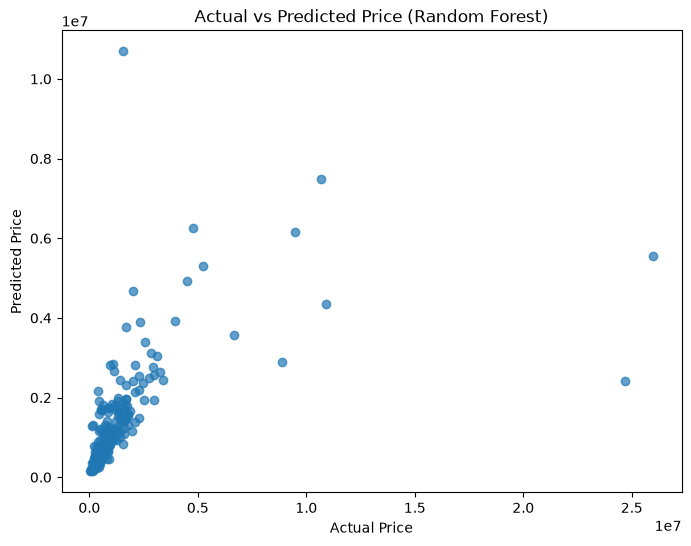

In [71]:
# visualize actual vs predicted prices 

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (Random Forest)")
plt.show()

        Feature  Importance
0         Brand    0.344426
3     km_Driven    0.234450
2          Year    0.154869
1         model    0.133796
4  Transmission    0.089601
6      FuelType    0.035813
5         Owner    0.007046


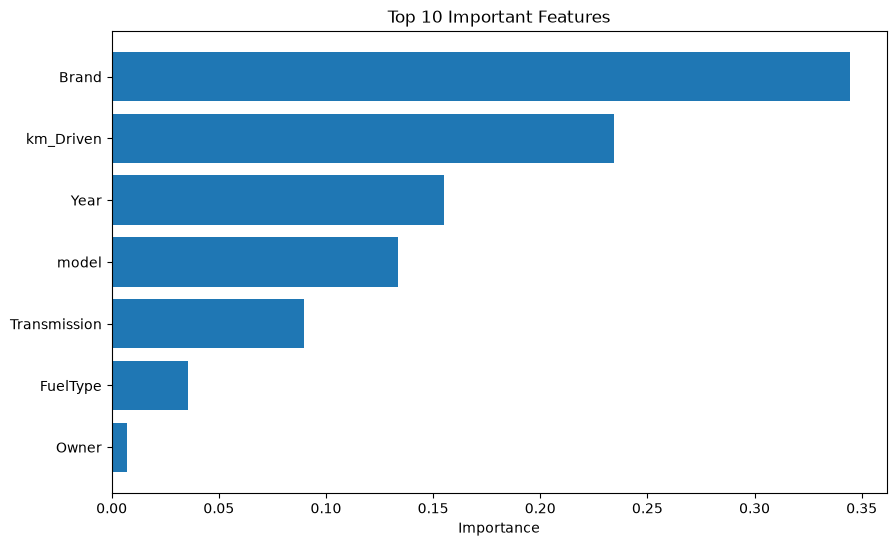

In [72]:
# plot feature importance

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"][:10],
         feature_importance["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

In [73]:
# comparison table

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb)
    ]
})

comparison = comparison.sort_values(by="R2 Score", ascending=False)

print(comparison)

               Model  R2 Score            MAE
2      Random Forest  0.304721  621251.133839
3  Gradient Boosting  0.209419  626944.763459
0  Linear Regression  0.131558  934863.501860
1      Decision Tree -0.200258  800482.008547


In [74]:
# save the best model

import joblib

joblib.dump(rf, "used_car_price_prediction.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [75]:
sample = X_test.iloc[[0]]

prediction = rf.predict(sample)

print("Predicted Price :", prediction[0])
print("Actual Price :", y_test.iloc[0])

Predicted Price : 2356515.0
Actual Price : 2450000


In [76]:
print(X)


      Brand  model  Year  km_Driven  Transmission  Owner  FuelType
0         8     48  2001    98000.0             1      1         1
1        27    116  2009   190000.0             1      1         0
2        28    196  2010    77246.0             1      0         0
3        18    177  2017    83500.0             1      1         0
4        18     27  2019    45000.0             0      0         1
...     ...    ...   ...        ...           ...    ...       ...
1207     17    215  2013    49200.0             1      0         0
1208      2    207  2021    21000.0             0      0         1
1209     27     40  2023    10000.0             0      0         1
1210     27    116  2006   170000.0             1      1         0
1211     24     68  2016    63000.0             1      1         0

[1168 rows x 7 columns]


In [77]:
print(df_used_car_dataset.columns)

Index(['Brand', 'model', 'Year', 'km_Driven', 'Transmission', 'Owner',
       'FuelType', 'Price(Rs)'],
      dtype='str')


In [78]:
import os

print(os.getcwd())


C:\Users\SMIT\onedrive\desktop\ML Project


In [79]:
model = joblib.load("used_car_price_prediction.pkl")
print(type(model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [80]:
encoders = joblib.load("label_encoders.pkl")
print(encoders.keys())

dict_keys(['Brand', 'model', 'Transmission', 'Owner', 'FuelType'])


In [81]:
print(X.columns.tolist())

['Brand', 'model', 'Year', 'km_Driven', 'Transmission', 'Owner', 'FuelType']


In [82]:
model = joblib.load("used_car_price_prediction.pkl")
print(type(model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
